# Single-Feature Clustering and Robustness Sweep — 7B

**Purpose:**
1. Run a single-feature sweep over all L1 features to identify the best discriminating feature.
2. Run a robustness sweep on that single best feature: for each subset size x, repeatedly
   draw x/2 emotional and x/2 neutral prompts per run, run k-means on the single feature,
   and record accuracy. Plot mean ± 1 SD vs x.

**Why single feature only:**
The single best feature (core_power.throttle__mean_rate) is the primary result.
The robustness sweep on this feature alone isolates whether the signal is stable
across prompt subsets without the noise introduced by greedy multi-feature selection.

## §1 — Imports and configuration

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, confusion_matrix

warnings.filterwarnings('ignore')
BASE_DIR   = Path.home() / 'Desktop' / 'mccviahat'
# DATA_DIR   = BASE_DIR / 'data' / 'clemsonc6420'
DATA_DIR   = BASE_DIR / 'data' / 'clemsonc6420'

RESULT_DIR = BASE_DIR / 'results' / 'hat_analysis'
RESULT_DIR.mkdir(parents=True, exist_ok=True)

assert BASE_DIR.exists(), f'Repo root not found: {BASE_DIR}'

# ── Runs to load ──────────────────────────────────────────────────────────────
# Add or remove run labels here as new data arrives
RUNS = ['A', 'B', 'D', 'E', 'F', 'AA', 'AB', 'AC', '1', '2', '3','4']

# ── L1 indicators ──────────────────────────────────────────────────────────────
L1_INDICATORS = [
    'hat_TLB',
    'tlb:tlb_flush',
    'core_power.throttle',
]

# ── Robustness sweep config ────────────────────────────────────────────────────
SUBSET_SIZES = [22, 24, 26, 28, 30, 32, 34, 36, 38, 40]
N_REPEATS    = 20
N_INIT       = 50
RAND_SEED    = 42

print('Configuration OK')
print(f'  Runs         : {RUNS}')
print(f'  Subset sizes : {SUBSET_SIZES}')
print(f'  Repeats      : {N_REPEATS}')

Configuration OK
  Runs         : ['A', 'B', 'D', 'E', 'F', 'AA', 'AB', 'AC', '1', '2', '3', '4']
  Subset sizes : [22, 24, 26, 28, 30, 32, 34, 36, 38, 40]
  Repeats      : 20


## §2 — Load data

In [2]:
dfs = []
runs_loaded = []
for run in RUNS:
    for stem in [f'independent{run}', run]:
        p = DATA_DIR / f'{stem}.csv'
        if p.exists():
            d = pd.read_csv(p)
            d['run'] = run
            dfs.append(d)
            runs_loaded.append(run)
            break
    else:
        print(f'  WARNING: no CSV found for run {run}')

assert dfs, 'No data loaded. Check DATA_DIR and RUNS.'
df_all = pd.concat(dfs, ignore_index=True)
df_all['label'] = (df_all['condition'] == 'emotional').astype(int)

print(f'Loaded {len(runs_loaded)} runs: {runs_loaded}')
print(f'  Total trials : {len(df_all)}')
print(f'  Emotional    : {(df_all.condition == "emotional").sum()}')
print(f'  Neutral      : {(df_all.condition == "neutral").sum()}')

Loaded 12 runs: ['A', 'B', 'D', 'E', 'F', 'AA', 'AB', 'AC', '1', '2', '3', '4']
  Total trials : 480
  Emotional    : 240
  Neutral      : 240


## §3 — Select L1 features

In [3]:
def indicator_of(col):
    for ind in L1_INDICATORS:
        if col.startswith(ind + '__'):
            return ind
    return ''

l1_cols = [c for c in df_all.columns if indicator_of(c) in L1_INDICATORS]

X_l1 = df_all[l1_cols].copy()
X_l1 = X_l1.dropna(axis=1, how='all')
X_l1 = X_l1.fillna(X_l1.median())
X_l1 = X_l1.loc[:, X_l1.std() > 0]

print(f'L1 features available: {X_l1.shape[1]}')

L1 features available: 30


## §4 — Single-feature sweep: find the best feature

In [ ]:
def kmeans_acc_ari(X, y, n_init=50, seed=42):
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)
    km = KMeans(n_clusters=2, n_init=n_init, random_state=seed)
    pred = km.fit_predict(Xs)
    cm = confusion_matrix(y, pred)
    if cm.shape != (2, 2):
        return 0.5, 0.0
    acc = max(
        (cm[0,0] + cm[1,1]) / cm.sum(),
        (cm[0,1] + cm[1,0]) / cm.sum()
    )
    ari = adjusted_rand_score(y, pred)
    return float(acc), float(ari)


y_true = df_all['label'].values
records = []
for col in X_l1.columns:
    acc, ari = kmeans_acc_ari(X_l1[[col]].values, y_true, n_init=N_INIT, seed=RAND_SEED)
    records.append({'feature': col, 'indicator': indicator_of(col),
                    'metric': col.split('__')[-1], 'accuracy': acc, 'ari': ari})

sf = pd.DataFrame(records).sort_values('accuracy', ascending=False).reset_index(drop=True)

BEST_FEATURE = sf.iloc[0]['feature']
BEST_ACC     = sf.iloc[0]['accuracy']
BEST_ARI     = sf.iloc[0]['ari']

print(f'Best single feature : {BEST_FEATURE}')
print(f'  Accuracy          : {BEST_ACC:.4f}')
print(f'  ARI               : {BEST_ARI:.4f}')
print()
print('Top 5:')
print(sf[['feature','accuracy','ari']].head(5).to_string(index=False))

Best single feature : core_power.throttle__spectral_entropy
  Accuracy          : 0.5417
  ARI               : 0.0049

Top 5:
                              feature  accuracy      ari
       core_power.throttle__mean_rate  0.543750 0.005580
core_power.throttle__spectral_entropy  0.541667 0.004876
      tlb:tlb_flush__burst_clustering  0.535417 0.003038
                  hat_TLB__burst_rate  0.531250 0.001835
      core_power.throttle__burst_rate  0.527083 0.000850


## §5 — Robustness sweep on the best single feature

For each subset size x and each of the 20 repeats:
- Draw x/2 emotional and x/2 neutral **prompt indices** uniformly at random.
- Select all trials (across all runs) matching those prompt indices.
- Run k-means on the single best feature.
- Record accuracy and ARI.

This tests whether the signal in the best feature is stable across
different prompt subsets, without the inflation from greedy feature selection.

In [5]:
# All prompt indices per condition
emotional_prompts = sorted(df_all[df_all.condition == 'emotional']['prompt_index'].unique())
neutral_prompts   = sorted(df_all[df_all.condition == 'neutral']['prompt_index'].unique())

print(f'Emotional prompt indices ({len(emotional_prompts)}): {emotional_prompts}')
print(f'Neutral prompt indices   ({len(neutral_prompts)}):   {neutral_prompts}')

Emotional prompt indices (20): [np.int64(0), np.int64(1), np.int64(2), np.int64(7), np.int64(8), np.int64(13), np.int64(14), np.int64(18), np.int64(24), np.int64(25), np.int64(28), np.int64(29), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39)]
Neutral prompt indices   (20):   [np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(15), np.int64(16), np.int64(17), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(26), np.int64(27), np.int64(30), np.int64(31)]


In [6]:
rng = np.random.default_rng(RAND_SEED)
results = []

for x in SUBSET_SIZES:
    half = x // 2
    assert half <= min(len(emotional_prompts), len(neutral_prompts)), \
        f'x/2={half} exceeds available prompts per condition'

    accs, aris = [], []
    for _ in range(N_REPEATS):
        e_sel = rng.choice(emotional_prompts, size=half, replace=False)
        n_sel = rng.choice(neutral_prompts,   size=half, replace=False)

        mask = (
            ((df_all.condition == 'emotional') & (df_all.prompt_index.isin(e_sel))) |
            ((df_all.condition == 'neutral')   & (df_all.prompt_index.isin(n_sel)))
        )
        sub = df_all[mask].copy()

        X_sub = sub[[BEST_FEATURE]].fillna(sub[[BEST_FEATURE]].median()).values
        y_sub = sub['label'].values

        if len(np.unique(y_sub)) < 2:
            continue

        acc, ari = kmeans_acc_ari(X_sub, y_sub, n_init=N_INIT, seed=RAND_SEED)
        accs.append(acc)
        aris.append(ari)

    results.append({
        'x':        x,
        'total':    x * len(runs_loaded),
        'mean_acc': np.mean(accs),
        'std_acc':  np.std(accs),
        'mean_ari': np.mean(aris),
        'std_ari':  np.std(aris),
    })
    print(f'  x={x:2d}  total={x*len(runs_loaded):4d}  '
          f'mean_acc={np.mean(accs):.4f}  ±{np.std(accs):.4f}  '
          f'mean_ARI={np.mean(aris):.4f}')

res = pd.DataFrame(results)

  x=22  total= 264  mean_acc=0.5447  ±0.0225  mean_ARI=0.0063
  x=24  total= 288  mean_acc=0.5476  ±0.0118  mean_ARI=0.0062
  x=26  total= 312  mean_acc=0.5452  ±0.0168  mean_ARI=0.0061
  x=28  total= 336  mean_acc=0.5454  ±0.0184  mean_ARI=0.0067
  x=30  total= 360  mean_acc=0.5347  ±0.0138  mean_ARI=0.0028
  x=32  total= 384  mean_acc=0.5439  ±0.0083  mean_ARI=0.0054
  x=34  total= 408  mean_acc=0.5407  ±0.0078  mean_ARI=0.0044
  x=36  total= 432  mean_acc=0.5442  ±0.0095  mean_ARI=0.0059
  x=38  total= 456  mean_acc=0.5406  ±0.0042  mean_ARI=0.0045
  x=40  total= 480  mean_acc=0.5417  ±0.0000  mean_ARI=0.0049


## §6 — Plot

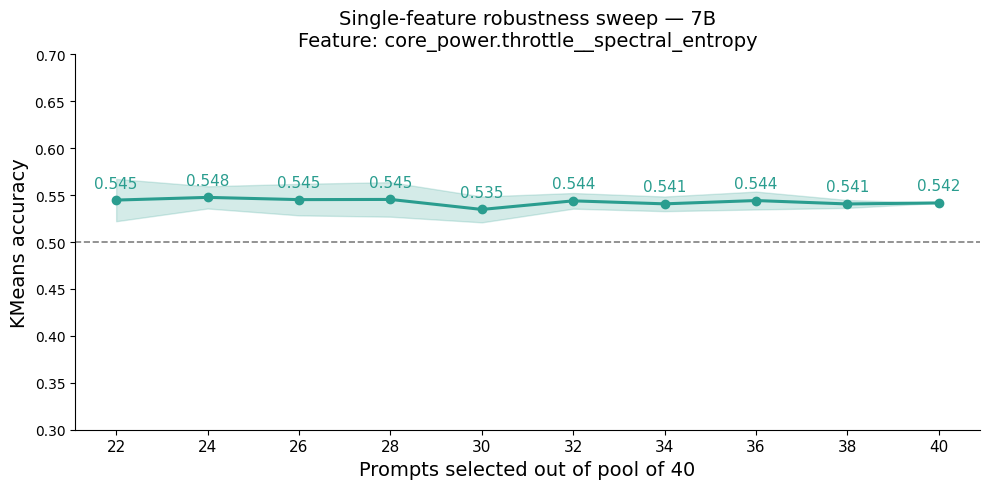

Saved: /Users/rsalvi/Desktop/mccviahat/results/hat_analysis/single_feature_robustness_7b.png


In [7]:
COLOR = '#2a9d8f'

xs   = res['x'].values
mean = res['mean_acc'].values
std  = res['std_acc'].values

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(xs, mean, marker='o', lw=2.2, color=COLOR, zorder=3,
        label=f'Best feature: {BEST_FEATURE}')
ax.fill_between(xs, mean - std, mean + std,
                alpha=0.20, color=COLOR, label='± 1 SD across 20 repeats')

for xi, mi in zip(xs, mean):
    ax.annotate(f'{mi:.3f}', (xi, mi),
                textcoords='offset points', xytext=(0, 9),
                ha='center', fontsize=11, color=COLOR)

ax.axhline(0.5, color='grey', lw=1.2, ls='--', label='Chance (0.50)')

ax.set_xlabel('Prompts selected out of pool of 40', fontsize=14)
ax.set_ylabel('KMeans accuracy', fontsize=14)
ax.set_title(
    f'Single-feature robustness sweep — 7B\n'
    f'Feature: {BEST_FEATURE}',
    fontsize=14
)
ax.set_xticks(xs)
ax.set_xticklabels([str(xi) for xi in xs], fontsize=11)
ax.set_ylim(0.3, 0.7)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
out = RESULT_DIR / 'single_feature_robustness_7b.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')

## §7 — Summary table

In [8]:
print('Single-feature robustness sweep — 7B')
print(f'Best feature: {BEST_FEATURE}')
print(f'Full-dataset accuracy (x=40): {res[res.x==40].mean_acc.values[0]:.4f}')
print()
print(f'  {"x":>4}  {"total":>6}  {"mean acc":>9}  {"± SD":>7}  {"mean ARI":>9}  {"± SD":>7}')
print('-' * 60)
for _, r in res.iterrows():
    print(f'  {int(r.x):>4}  {int(r.total):>6}  {r.mean_acc:>9.4f}  '
          f'{r.std_acc:>7.4f}  {r.mean_ari:>9.4f}  {r.std_ari:>7.4f}')
print()
print(f'Chance baseline: 0.5000')

Single-feature robustness sweep — 7B
Best feature: core_power.throttle__spectral_entropy
Full-dataset accuracy (x=40): 0.5417

     x   total   mean acc     ± SD   mean ARI     ± SD
------------------------------------------------------------
    22     264     0.5447   0.0225     0.0063   0.0109
    24     288     0.5476   0.0118     0.0062   0.0045
    26     312     0.5452   0.0168     0.0061   0.0059
    28     336     0.5454   0.0184     0.0067   0.0075
    30     360     0.5347   0.0138     0.0028   0.0044
    32     384     0.5439   0.0083     0.0054   0.0030
    34     408     0.5407   0.0078     0.0044   0.0027
    36     432     0.5442   0.0095     0.0059   0.0032
    38     456     0.5406   0.0042     0.0045   0.0014
    40     480     0.5417   0.0000     0.0049   0.0000

Chance baseline: 0.5000


In [9]:
for cond in ['emotional', 'neutral']:
    vals = df_all[df_all.condition == cond][BEST_FEATURE].dropna()
    print(f'{cond:10s}  n={len(vals):4d}  mean={vals.mean():.2f}  median={vals.median():.2f}  std={vals.std():.2f}')

emotional   n= 240  mean=0.56  median=0.56  std=0.08
neutral     n= 240  mean=0.55  median=0.54  std=0.09


In [10]:
FEATURE = 'core_power.throttle__mean_rate'

for cond in ['emotional', 'neutral']:
    sub = df_all[df_all.condition == cond].copy().reset_index(drop=True)

    # Pseudo ground truth: rank trials by index, assign first half label 0, second half label 1
    # This guarantees exactly 50/50 split regardless of prompt index distribution
    n = len(sub)
    pseudo = np.zeros(n, dtype=int)
    pseudo[n // 2:] = 1
    # Shuffle by prompt index to avoid positional bias
    order = sub['prompt_index'].argsort().values
    sub = sub.iloc[order].reset_index(drop=True)
    sub['pseudo_label'] = pseudo

    X = sub[[FEATURE]].fillna(sub[[FEATURE]].median()).values
    y = sub['pseudo_label'].values

    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)
    km = KMeans(n_clusters=2, n_init=N_INIT, random_state=RAND_SEED)
    pred = km.fit_predict(Xs)

    cm = confusion_matrix(y, pred)
    acc = max(
        (cm[0,0] + cm[1,1]) / cm.sum(),
        (cm[0,1] + cm[1,0]) / cm.sum()
    )
    ari = adjusted_rand_score(y, pred)

    print(f'{cond:10s}  n={len(sub):4d}  label_0={( y==0).sum()}  label_1={(y==1).sum()}')
    print(f'  acc={acc:.4f}  ARI={ari:.4f}')
    print(f'  Expected: acc ≈ 0.50, ARI ≈ 0.00')
    print()

emotional   n= 240  label_0=120  label_1=120
  acc=0.5458  ARI=0.0043
  Expected: acc ≈ 0.50, ARI ≈ 0.00

neutral     n= 240  label_0=120  label_1=120
  acc=0.6167  ARI=0.0505
  Expected: acc ≈ 0.50, ARI ≈ 0.00



1. Mean throttle rate by prompt index
 prompt_index condition  core_power.throttle__mean_rate
            0 emotional                    66741.370139
            1 emotional                    76319.016764
            2 emotional                    75588.747903
            3   neutral                    58494.975578
            4   neutral                    81365.786770
            5   neutral                    75390.888241
            6   neutral                    66705.985344
            7 emotional                    80437.757400
            8 emotional                    74356.319113
            9   neutral                    80033.973827
           10   neutral                    78907.937123
           11   neutral                    80622.324843
           12   neutral                    80048.353903
           13 emotional                    86731.035134
           14 emotional                    83881.370162
           15   neutral                    72066.946371
          

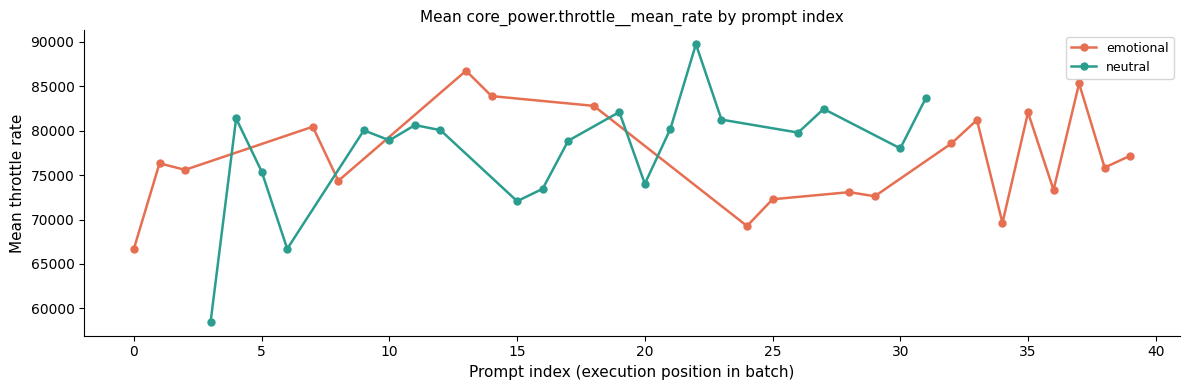

emotional   Spearman r=-0.0032  p=0.9601
neutral     Spearman r=0.2783  p=0.0000

2. Mean throttle rate by run
run condition  core_power.throttle__mean_rate
  1 emotional                    75573.840580
  1   neutral                    76916.629074
  2 emotional                    75192.503258
  2   neutral                    74633.642384
  3 emotional                    66617.845685
  3   neutral                    68116.466040
  4 emotional                    73488.436185
  4   neutral                    75361.940853
  A emotional                    76529.396260
  A   neutral                    78034.182959
 AA emotional                    88582.108235
 AA   neutral                    89712.948474
 AB emotional                    85473.033195
 AB   neutral                    84458.652079
 AC emotional                    87477.584151
 AC   neutral                    89023.284252
  B emotional                    74124.890999
  B   neutral                    73523.223392
  D emotional  

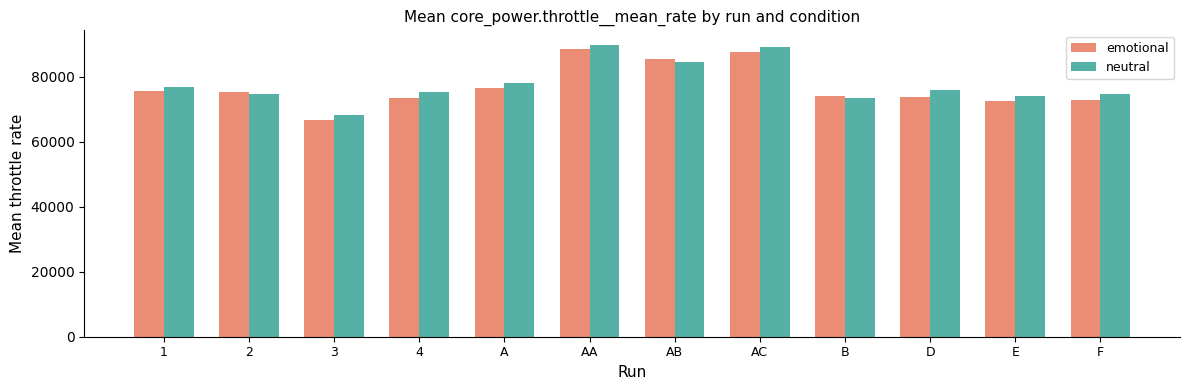

Per-run Mann-Whitney U test (emotional vs neutral):
  Run           U           p     direction
---------------------------------------------
    1       173.0      0.4735     ↑ neutral
    2       211.0      0.7764   ↑ emotional
    3       156.0      0.2393     ↑ neutral
    4       167.0      0.3793     ↑ neutral
    A       162.0      0.3104     ↑ neutral
   AA       184.0      0.6750     ↑ neutral
   AB       211.0      0.7764   ↑ emotional
   AC       177.0      0.5428     ↑ neutral
    B       201.0      0.9892   ↑ emotional
    D       172.0      0.4570     ↑ neutral
    E       176.0      0.5250     ↑ neutral
    F       154.0      0.2184     ↑ neutral

3. Partial correlation: condition vs throttle, controlling for prompt index
Raw correlation       (condition vs throttle):              r=-0.0467  p=0.3073
Partial correlation   (after removing prompt index effect): r=-0.0844  p=0.0646

4. Early (indices 0-19) vs late (indices 20-39) throttle rates
emotional   early mean=78354.

In [11]:
import scipy.stats as stats

FEATURE = 'core_power.throttle__mean_rate'

# ── 1. Mean throttle rate by prompt index position ─────────────────────────────
print("=" * 60)
print("1. Mean throttle rate by prompt index")
print("=" * 60)
by_prompt = df_all.groupby(['prompt_index', 'condition'])[FEATURE].mean().reset_index()
print(by_prompt.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 4))
for cond, color in [('emotional', '#e76f51'), ('neutral', '#2a9d8f')]:
    sub = by_prompt[by_prompt.condition == cond].sort_values('prompt_index')
    ax.plot(sub['prompt_index'], sub[FEATURE], marker='o', lw=1.8,
            color=color, label=cond, markersize=5)
ax.set_xlabel('Prompt index (execution position in batch)', fontsize=11)
ax.set_ylabel('Mean throttle rate', fontsize=11)
ax.set_title('Mean core_power.throttle__mean_rate by prompt index', fontsize=11)
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('throttle_by_prompt_index.png', dpi=150, bbox_inches='tight')
plt.show()

# Spearman correlation between prompt index and throttle rate (all trials)
for cond in ['emotional', 'neutral']:
    sub = df_all[df_all.condition == cond]
    r, p = stats.spearmanr(sub['prompt_index'], sub[FEATURE].fillna(sub[FEATURE].median()))
    print(f'{cond:10s}  Spearman r={r:.4f}  p={p:.4f}')

print()

# ── 2. Mean throttle rate by run ───────────────────────────────────────────────
print("=" * 60)
print("2. Mean throttle rate by run")
print("=" * 60)
by_run = df_all.groupby(['run', 'condition'])[FEATURE].mean().reset_index()
print(by_run.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 4))
runs_sorted = sorted(df_all['run'].unique())
x = np.arange(len(runs_sorted))
width = 0.35
for i, (cond, color) in enumerate([('emotional', '#e76f51'), ('neutral', '#2a9d8f')]):
    vals = [by_run[(by_run.run == r) & (by_run.condition == cond)][FEATURE].values[0]
            if len(by_run[(by_run.run == r) & (by_run.condition == cond)]) > 0
            else np.nan for r in runs_sorted]
    ax.bar(x + i * width, vals, width, label=cond, color=color, alpha=0.8)
ax.set_xticks(x + width / 2)
ax.set_xticklabels(runs_sorted, fontsize=9)
ax.set_xlabel('Run', fontsize=11)
ax.set_ylabel('Mean throttle rate', fontsize=11)
ax.set_title('Mean core_power.throttle__mean_rate by run and condition', fontsize=11)
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('throttle_by_run.png', dpi=150, bbox_inches='tight')
plt.show()

# Mann-Whitney U between emotional and neutral per run
print("Per-run Mann-Whitney U test (emotional vs neutral):")
print(f"{'Run':>5}  {'U':>10}  {'p':>10}  {'direction':>12}")
print("-" * 45)
for run in runs_sorted:
    e = df_all[(df_all.run == run) & (df_all.condition == 'emotional')][FEATURE].dropna()
    n = df_all[(df_all.run == run) & (df_all.condition == 'neutral')][FEATURE].dropna()
    if len(e) > 1 and len(n) > 1:
        u, p = stats.mannwhitneyu(e, n, alternative='two-sided')
        direction = '↑ emotional' if e.mean() > n.mean() else '↑ neutral'
        print(f'{run:>5}  {u:>10.1f}  {p:>10.4f}  {direction:>12}')
print()

# ── 3. Partial correlation controlling for prompt index ────────────────────────
print("=" * 60)
print("3. Partial correlation: condition vs throttle, controlling for prompt index")
print("=" * 60)
from scipy.stats import pearsonr

df_tmp = df_all[['condition', 'prompt_index', FEATURE]].dropna().copy()
df_tmp['cond_binary'] = (df_tmp['condition'] == 'emotional').astype(float)

# Residualise both variables against prompt index
def residualise(y, x):
    slope, intercept, _, _, _ = stats.linregress(x, y)
    return y - (slope * x + intercept)

x = df_tmp['prompt_index'].values.astype(float)
y_cond     = df_tmp['cond_binary'].values
y_throttle = df_tmp[FEATURE].values

res_cond     = residualise(y_cond,     x)
res_throttle = residualise(y_throttle, x)

r_raw,     p_raw     = pearsonr(y_cond, y_throttle)
r_partial, p_partial = pearsonr(res_cond, res_throttle)

print(f'Raw correlation       (condition vs throttle):              r={r_raw:.4f}  p={p_raw:.4f}')
print(f'Partial correlation   (after removing prompt index effect): r={r_partial:.4f}  p={p_partial:.4f}')
print()

# ── 4. Early (0-19) vs late (20-39) prompt positions ──────────────────────────
print("=" * 60)
print("4. Early (indices 0-19) vs late (indices 20-39) throttle rates")
print("=" * 60)
for cond in ['emotional', 'neutral']:
    sub = df_all[df_all.condition == cond]
    early = sub[sub['prompt_index'] <= 19][FEATURE].dropna()
    late  = sub[sub['prompt_index'] >  19][FEATURE].dropna()
    u, p  = stats.mannwhitneyu(early, late, alternative='two-sided')
    print(f'{cond:10s}  early mean={early.mean():.2f} (n={len(early)})  '
          f'late mean={late.mean():.2f} (n={len(late)})  '
          f'MWU p={p:.4f}')

print()
early_e = df_all[(df_all.condition == 'emotional') & (df_all.prompt_index <= 19)][FEATURE].dropna()
late_e  = df_all[(df_all.condition == 'emotional') & (df_all.prompt_index >  19)][FEATURE].dropna()
early_n = df_all[(df_all.condition == 'neutral')   & (df_all.prompt_index <= 19)][FEATURE].dropna()
late_n  = df_all[(df_all.condition == 'neutral')   & (df_all.prompt_index >  19)][FEATURE].dropna()

print("Prompt index distribution per condition:")
print(f"  emotional  early indices: {sorted(df_all[(df_all.condition=='emotional') & (df_all.prompt_index<=19)]['prompt_index'].unique())}")
print(f"  emotional  late  indices: {sorted(df_all[(df_all.condition=='emotional') & (df_all.prompt_index> 19)]['prompt_index'].unique())}")
print(f"  neutral    early indices: {sorted(df_all[(df_all.condition=='neutral')   & (df_all.prompt_index<=19)]['prompt_index'].unique())}")
print(f"  neutral    late  indices: {sorted(df_all[(df_all.condition=='neutral')   & (df_all.prompt_index> 19)]['prompt_index'].unique())}")

Linear fit: throttle = 114.96 * prompt_index + 75113.92
Residual mean: 0.0000  (should be ~0)
Residual std:  10607.18

Clustering on position-residualised throttle:
  acc=0.5479  ARI=0.0071
  Chance: acc=0.5000  ARI=0.0000

emotional   mean=-860.73  median=-1631.95  std=10643.45
neutral     mean=860.73  median=702.19  std=10522.57


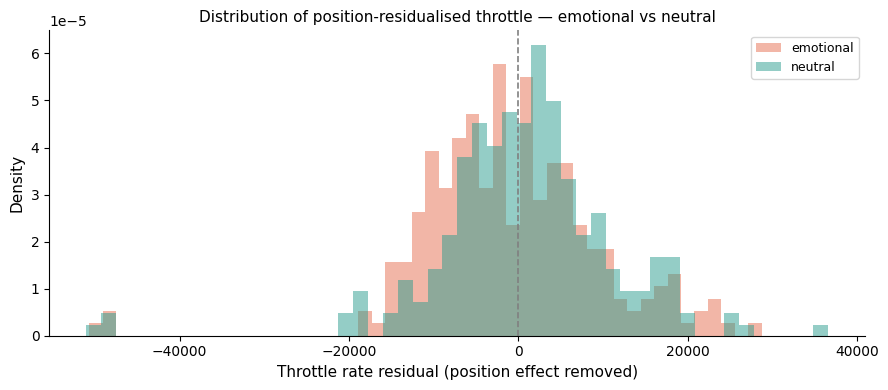

In [12]:
from scipy.stats import linregress

FEATURE = 'core_power.throttle__mean_rate'

# ── Residualise throttle against prompt index ──────────────────────────────────
df_res = df_all[['condition', 'prompt_index', 'run', FEATURE]].dropna().copy()

x = df_res['prompt_index'].values.astype(float)
y = df_res[FEATURE].values.astype(float)

slope, intercept, _, _, _ = linregress(x, y)
df_res['throttle_residual'] = y - (slope * x + intercept)

print(f'Linear fit: throttle = {slope:.2f} * prompt_index + {intercept:.2f}')
print(f'Residual mean: {df_res.throttle_residual.mean():.4f}  (should be ~0)')
print(f'Residual std:  {df_res.throttle_residual.std():.2f}')
print()

# ── K-means on residuals ───────────────────────────────────────────────────────
y_true = (df_res['condition'] == 'emotional').astype(int).values
X = df_res[['throttle_residual']].values

scaler = StandardScaler()
Xs = scaler.fit_transform(X)
km = KMeans(n_clusters=2, n_init=N_INIT, random_state=RAND_SEED)
pred = km.fit_predict(Xs)

cm = confusion_matrix(y_true, pred)
acc = max(
    (cm[0,0] + cm[1,1]) / cm.sum(),
    (cm[0,1] + cm[1,0]) / cm.sum()
)
ari = adjusted_rand_score(y_true, pred)

print(f'Clustering on position-residualised throttle:')
print(f'  acc={acc:.4f}  ARI={ari:.4f}')
print(f'  Chance: acc=0.5000  ARI=0.0000')
print()

# ── Distribution of residuals per condition ────────────────────────────────────
for cond in ['emotional', 'neutral']:
    vals = df_res[df_res.condition == cond]['throttle_residual']
    print(f'{cond:10s}  mean={vals.mean():.2f}  median={vals.median():.2f}  std={vals.std():.2f}')

# ── Plot residual distributions ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
for cond, color in [('emotional', '#e76f51'), ('neutral', '#2a9d8f')]:
    vals = df_res[df_res.condition == cond]['throttle_residual']
    ax.hist(vals, bins=50, alpha=0.5, color=color, label=cond, density=True)
ax.axvline(0, color='grey', lw=1.2, ls='--')
ax.set_xlabel('Throttle rate residual (position effect removed)', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('Distribution of position-residualised throttle — emotional vs neutral', fontsize=11)
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('throttle_residual_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
from scipy.stats import linregress

# ── Residualise all L1 features against prompt index ───────────────────────────
x_pos = df_all['prompt_index'].values.astype(float)

X_l1_resid = X_l1.copy()
for col in X_l1.columns:
    y_col = X_l1[col].values.astype(float)
    slope, intercept, _, _, _ = linregress(x_pos, y_col)
    X_l1_resid[col] = y_col - (slope * x_pos + intercept)

print('Residualised all L1 features against prompt_index.')
print(f'Features: {X_l1_resid.shape[1]}')
print()

# ── Direction helper ───────────────────────────────────────────────────────────
def direction(col, df, resid=False):
    src = X_l1_resid if resid else X_l1
    e = src.loc[df['condition'] == 'emotional', col].mean()
    n = src.loc[df['condition'] == 'neutral',   col].mean()
    return '↑E' if e > n else '↑N'

# ── Single-feature sweep on residuals ─────────────────────────────────────────
y_true = df_all['label'].values
records_resid = []
for col in X_l1_resid.columns:
    acc, ari = kmeans_acc_ari(X_l1_resid[[col]].values, y_true,
                              n_init=N_INIT, seed=RAND_SEED)
    records_resid.append({
        'feature':   col,
        'indicator': indicator_of(col),
        'metric':    col.split('__')[-1],
        'accuracy':  acc,
        'ari':       ari,
        'direction': direction(col, df_all, resid=True),
    })

sf_resid = pd.DataFrame(records_resid).sort_values('accuracy', ascending=False).reset_index(drop=True)

BEST_FEATURE_R = sf_resid.iloc[0]['feature']
BEST_ACC_R     = sf_resid.iloc[0]['accuracy']
BEST_ARI_R     = sf_resid.iloc[0]['ari']

print(f'Best single feature (position-residualised): {BEST_FEATURE_R}')
print(f'  Accuracy  : {BEST_ACC_R:.4f}')
print(f'  ARI       : {BEST_ARI_R:.4f}')
print(f'  Direction : {sf_resid.iloc[0]["direction"]}')
print()
print('Top 10 (residualised):')
print(sf_resid[['feature','accuracy','ari','direction']].head(10).to_string(index=False))
print()

# ── Side-by-side comparison with original ─────────────────────────────────────
print('Comparison — original vs position-residualised (top 10 original):')
print(f'{"feature":<50}  {"orig acc":>9}  {"resid acc":>10}  {"delta":>7}  {"dir(orig)":>10}  {"dir(resid)":>11}')
print('-' * 105)
for _, row in sf.head(10).iterrows():
    orig_acc  = row['accuracy']
    resid_row = sf_resid[sf_resid.feature == row['feature']].iloc[0]
    resid_acc = resid_row['accuracy']
    delta     = resid_acc - orig_acc
    dir_orig  = direction(row['feature'], df_all, resid=False)
    dir_resid = resid_row['direction']
    print(f'{row["feature"]:<50}  {orig_acc:>9.4f}  {resid_acc:>10.4f}  '
          f'{delta:>+7.4f}  {dir_orig:>10}  {dir_resid:>11}')

Residualised all L1 features against prompt_index.
Features: 30

Best single feature (position-residualised): core_power.throttle__mean_rate
  Accuracy  : 0.5479
  ARI       : 0.0071
  Direction : ↑N

Top 10 (residualised):
                              feature  accuracy      ari direction
       core_power.throttle__mean_rate  0.547917 0.007130        ↑N
core_power.throttle__spectral_entropy  0.541667 0.004881        ↑E
                  hat_TLB__burst_rate  0.529167 0.001332        ↑N
      tlb:tlb_flush__burst_clustering  0.529167 0.001424        ↑N
      core_power.throttle__burst_rate  0.529167 0.001323        ↑N
           core_power.throttle__slope  0.529167 0.001599        ↑N
         core_power.throttle__p90_p10  0.527083 0.001086        ↑N
core_power.throttle__burst_clustering  0.525000 0.000544        ↑N
            tlb:tlb_flush__burst_rate  0.522917 0.001658        ↑E
                tlb:tlb_flush__iat_cv  0.522917 0.000015        ↑E

Comparison — original vs position-resi